# 06. Cold-Start and A/B Test Design

## ?????
- [x] ?? ?? cold-start ???? ??
- [x] ??? ?? -> hybrid ?? ?????
- [x] ?? ??? cold-start ???? ??
- [x] Content-Based -> Hybrid ?? ?? ??
- [x] Cold-start ?? ?? ??
- [x] `? ? ??? ??? CF? ?? ???` ??
- [x] A/B ??? ?? ? ?? ??
- [x] offline -> online ?? ?? ??

In [1]:
from pathlib import Path
import subprocess
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data import load_bundle

sns.set_theme(style='whitegrid')

## 1. ??? ??

Day 5 ??? `scripts/generate_day5_artifacts.py`? ???? ? ????.
? ???? ??? CSV/JSON/PNG? ?? cold-start ????? A/B ??? ???? ?????.

In [2]:
transition_path = PROJECT_ROOT / 'artifacts' / 'metrics' / 'day5_cold_start_transition.csv'
new_item_path = PROJECT_ROOT / 'artifacts' / 'metrics' / 'day5_new_item_strategy.csv'
summary_path = PROJECT_ROOT / 'artifacts' / 'metrics' / 'day5_cold_start_summary.json'
figure_path = PROJECT_ROOT / 'artifacts' / 'figures' / 'day5_cold_start_transition.png'

if not transition_path.exists():
    subprocess.run([sys.executable, str(PROJECT_ROOT / 'scripts' / 'generate_day5_artifacts.py')], check=True)

bundle = load_bundle(download_if_missing=False)
transition_df = pd.read_csv(transition_path)
new_item_strategy_df = pd.read_csv(new_item_path)
summary_series = pd.read_json(summary_path, typ='series')
transition_df

,observed_ratings,stage,users_evaluated,precision@10,recall@10,ndcg@10,map@10,coverage
0,0,popularity,200.0,0.325000,0.086521,0.364042,0.219343,0.005945
1,1,content,200.0,0.066000,0.012104,0.074853,0.032032,0.234839
2,3,content,200.0,0.068500,0.013636,0.078259,0.032087,0.335315
3,5,hybrid,200.0,0.277500,0.088540,0.295368,0.181395,0.185493
4,10,hybrid,200.0,0.316500,0.107930,0.347979,0.225736,0.180737
5,15,hybrid,199.0,0.326633,0.120784,0.369016,0.241610,0.180737


## 2. ?? ?? ??? ??

0? ?? ??? ?? ?? ??? ?? ?????? coverage? ?? ????.
? ?? ??? ?? ??? content-only?? hybrid? personalization recovery? ? ???? ?????.

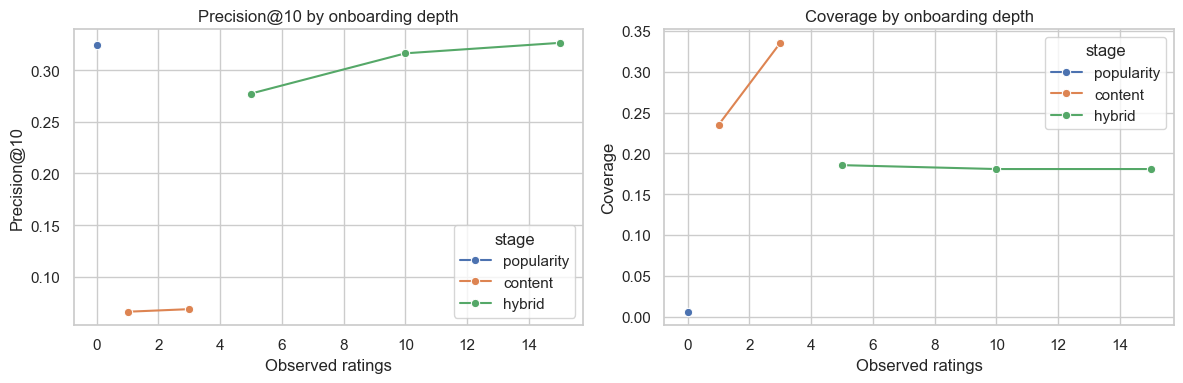

,observed_ratings,stage,users_evaluated,precision@10,recall@10,ndcg@10,map@10,coverage
0,0,popularity,200.0,0.325000,0.086521,0.364042,0.219343,0.005945
1,1,content,200.0,0.066000,0.012104,0.074853,0.032032,0.234839
2,3,content,200.0,0.068500,0.013636,0.078259,0.032087,0.335315
3,5,hybrid,200.0,0.277500,0.088540,0.295368,0.181395,0.185493
4,10,hybrid,200.0,0.316500,0.107930,0.347979,0.225736,0.180737
5,15,hybrid,199.0,0.326633,0.120784,0.369016,0.241610,0.180737


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.lineplot(data=transition_df, x='observed_ratings', y='precision@10', hue='stage', marker='o', ax=axes[0])
axes[0].set_title('Precision@10 by onboarding depth')
axes[0].set_xlabel('Observed ratings')
axes[0].set_ylabel('Precision@10')

sns.lineplot(data=transition_df, x='observed_ratings', y='coverage', hue='stage', marker='o', ax=axes[1])
axes[1].set_title('Coverage by onboarding depth')
axes[1].set_xlabel('Observed ratings')
axes[1].set_ylabel('Coverage')
plt.tight_layout()
plt.show()

transition_df

## 3. ?? ??? ??

?? ???? ??? ?? ?? ??? CF? ?? ??? ?????.
??? metadata? ?? ?? ?? ????? content-based ??? ????, ????? ??? hybrid? ??? ??? ???????.

In [4]:
new_item_strategy_df

,model_name,precision@10,coverage,cold_start_item_share,recommended_stage
0,content_tfidf_metadata,0.017171,0.368644,0.228618,metadata-only launch
1,switching_hybrid_lt_15,0.247300,0.209443,0.001404,early traction
2,weighted_hybrid_alpha_0.85,0.249676,0.180993,0.000000,steady state
3,popularity_baseline,0.134665,0.029056,0.000000,fallback baseline


## 4. A/B ???? ??

offline metric??? rollout ??? ??? ??, CTR? guardrail metric? ?? ?? ??? ??? ?????.

In [5]:
ab_test_path = PROJECT_ROOT / 'ab_test_design.md'
ab_text = ab_test_path.read_text(encoding='utf-8')
suffix = chr(10) * 2 + '...'
display(Markdown(ab_text[:2500] + suffix))

# A/B 테스트 설계: Hybrid 추천 vs Popularity 추천

## 1. 실험 목적

offline 평가에서 가장 높은 랭킹 품질을 보인 `weighted_hybrid_alpha_0.85`가 실제 추천 surface에서도 더 높은 engagement를 만드는지 검증한다.

## 2. 가설

- `H1`: Weighted Hybrid 추천은 popularity baseline 대비 추천 CTR을 개선한다.
- `H2`: Weighted Hybrid 추천은 상세 페이지 진입 이후 평균 평점 또는 positive feedback rate를 유지하거나 개선한다.
- `H3`: Switching fallback을 함께 두면 sparse profile user에서도 coverage 하락 없이 personalization을 도입할 수 있다.

## 3. 실험 대상

- 노출 위치: 홈 추천 shelf 또는 "당신을 위한 추천" 섹션
- 분석 단위: `user_id`
- 배정 단위: `user_id` 해시 기반 50:50 randomization
- 제외 대상:
  - 내부 테스트 계정
  - 신규 가입 직후 상호작용이 전혀 없는 유저
  - 추천 shelf가 렌더링되지 않은 세션

## 4. 실험군 구성

| Arm | 서빙 로직 | 목적 |
|---|---|---|
| Control | popularity baseline | 현재 기준선 |
| Treatment | weighted hybrid (`alpha=0.85`) | 개인화 랭킹 도입 |

운영 메모:

- 신규 유저나 sparse profile user는 treatment arm 안에서도 `switching_hybrid_lt_15` 또는 content fallback을 적용해 cold-start 리스크를 줄인다.
- 실험 로그에는 실제 노출된 모델 이름과 fallback 여부를 함께 저장한다.

## 5. 핵심 지표

### Primary metric

- 추천 CTR
- 추천 클릭 후 상세 페이지 dwell / watch intent proxy
- 추천 클릭 아이템의 평균 평점 또는 positive feedback rate

### Secondary metric

- 추천 shelf 기준 save / wishlist / add-to-cart 유사 이벤트
- 추천 이후 세션당 소비 아이템 수

### Guardrail metric

- Coverage
- catalog concentration
- hide / dislike / complaint rate
- cold-start item exposure share
- latency p95

## 6. 오프라인 지표와 온라인 지표 연결 논리

| Offline metric | Online expectation | 이유 |
|---|---|---|
| Precision@10 | CTR 상승 | 상단 추천 정확도가 높을수록 클릭 가능성이 높다. |
| NDCG@10 | CTR + dwell 상승 | 클릭 가치가 높은 아이템이 상단에 배치될수록 engagement가 좋아질 가능성이 높다. |
| Coverage | catalog exploration 개선 | 특정 인기 아이템 편중을 줄이면 long-tail 소비 기회가 늘어난다. |
| Intra-list Diversity | fatigue 완화 | 너무 비슷한 추천만 반복되면 피로도가 높아질 수 있다. |
| cold_start_item_share | 신규 아이템 학습 가속 | 신규 아이템이 노출되지 않으면 상호작용 자체가 쌓이지 않는다. |

주의점:

- 오프라인 성능이 높아도 UI, 노출 맥락, 탐색 행동에 따라 온라인 성과는 달라질 수 있다.
- 따라서 실험 로그에는 추천 점수만 아니라 노출 순위, 클릭, 후속 이벤트, fallback 여부를 함께 적재해야 한다.

## 7. 샘플 사이즈 산정 예시

가정:

- baseline CTR = `8.0%`
- 상대 개선 목표(MDE) = `+7.5%`
- treatment CTR 가정 = `8.6%`
- 유의수준 `alpha = 0.05`
- 검정력 `power = 0.80`

두 비율 비교 근사식 기준 필요 표본:

- 약 `33,151 users per arm`
- 총 `66,302 users`

운영 예시:

- 추천 shelf 노출 eligible user가 하루 10,000명이고 50:50 배정이면 arm당 하루 약 5,000명 수집 가능
- 이 경우 최소 `7일` 이상은 확보해야 계절성/요일 효과를 일부 완화하면서 표본도 채울 수 있다.

이 수치는 **실측값이 아니라 예시 가정**이다. 실제 서비스에서는 baseline CTR, traffic eligibility, novelty ratio를 반영해 재계산해야 한다.

## 8. 로그 설계

필수 컬럼:

- `event_time`
- `user_id`
- `experiment_id`
- `variant`
- `model_name`
- `fallback_reason`
- `request_id`
- `item_id`
- `ra

...

## 5. ??

- popularity? ?? cold-start ???? ??? ??????.
- metadata TF-IDF? ?? ??? ??? catalog coverage ??? ?????.
- pseudo-onboarding simulation ????? ? 10~15? ??? ?? ? hybrid? popularity ??? precision? ????? ??? ??????.
- ?? ??? ?? ??? ? ?? ???? feature flag? ?? online ???? ????? ?? ?????.

In [6]:
summary_series

best_precision_stage                                   {'observed_ratings': 15, 'stage': 'hybrid', 'u...
recommended_cf_switch_threshold                                                                        5
recommended_hybrid_threshold_for_precision_recovery                                                   15
dtype: object